# KPI Performance Analysis

This notebook focuses on evaluating the key business performance indicators of the marketing campaigns.

The analysis aims to understand overall campaign efficiency, identify high- and low-performing campaigns, establish KPI benchmarks, and classify campaigns based on their overall performance.

The key KPIs considered are:

- Click-Through Rate (CTR)
- Conversion Rate
- Cost Per Click (CPC)
- Cost Per Acquisition (CPA)
- Return on Ad Spend (ROAS)
- Profit
- Impressions
- Clicks
- Conversions
- Ad Spend
- Revenue

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv(
    "../data/processed/campaign_data_cleaned.csv"
)

# Convert date column
df["start_date"] = pd.to_datetime(df["start_date"])

print("Dataset Shape:", df.shape)

Dataset Shape: (10000, 40)


In [21]:
# ============================================================
# 4.1 OVERALL KPI SUMMARY
# ============================================================

kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Campaigns",
        "Total Impressions",
        "Total Clicks",
        "Total Conversions",
        "Total Ad Spend",
        "Total Revenue",
        "Total Profit",
        "Average CTR",
        "Average Conversion Rate",
        "Average CPC",
        "Average CPA",
        "Average ROAS"
    ],

    "Value": [
        df["campaign_id"].nunique(),
        df["impressions"].sum(),
        df["clicks"].sum(),
        df["conversions"].sum(),
        df["ad_spend"].sum(),
        df["revenue"].sum(),
        df["profit"].sum(),
        df["CTR"].mean(),
        df["conversion_rate"].mean(),
        df["CPC"].mean(),
        df["CPA"].mean(),
        df["ROAS"].mean()
    ]
})

# ============================================================
# FORMAT VALUES FOR READABILITY
# ============================================================

def format_kpi(row):
    metric = row["Metric"]
    value = row["Value"]

    # Campaign counts and volume metrics
    if metric in [
        "Total Campaigns",
        "Total Impressions",
        "Total Clicks",
        "Total Conversions"
    ]:
        return f"{value:,.0f}"

    # Financial metrics
    elif metric in [
        "Total Ad Spend",
        "Total Revenue",
        "Total Profit"
    ]:
        return f"${value:,.2f}"

    # Rate and efficiency metrics
    else:
        return f"{value:,.2f}"


kpi_summary["Value"] = kpi_summary.apply(
    format_kpi,
    axis=1
)

display(kpi_summary)

,Metric,Value
0,Total Campaigns,"10,000"
1,Total Impressions,"705,392,230"
2,Total Clicks,"15,264,361"
3,Total Conversions,"655,688"
4,Total Ad Spend,"$43,455,661.79"
5,Total Revenue,"$284,157,706.47"
6,Total Profit,"$240,702,044.68"
7,Average CTR,2.31
8,Average Conversion Rate,3.64
9,Average CPC,3.29


In [3]:
# ============================================================
# AGGREGATE KPI CALCULATIONS
# ============================================================

total_impressions = df["impressions"].sum()
total_clicks = df["clicks"].sum()
total_conversions = df["conversions"].sum()
total_ad_spend = df["ad_spend"].sum()
total_revenue = df["revenue"].sum()
total_profit = df["profit"].sum()

overall_ctr = (total_clicks / total_impressions) * 100

overall_conversion_rate = (
    total_conversions / total_clicks
) * 100

overall_cpc = (
    total_ad_spend / total_clicks
)

overall_cpa = (
    total_ad_spend / total_conversions
)

overall_roas = (
    total_revenue / total_ad_spend
)

aggregate_kpis = pd.DataFrame({
    "KPI": [
        "Overall CTR",
        "Overall Conversion Rate",
        "Overall CPC",
        "Overall CPA",
        "Overall ROAS"
    ],
    
    "Value": [
        overall_ctr,
        overall_conversion_rate,
        overall_cpc,
        overall_cpa,
        overall_roas
    ]
}).round(2)

display(aggregate_kpis)

,KPI,Value
0,Overall CTR,2.16
1,Overall Conversion Rate,4.30
2,Overall CPC,2.85
3,Overall CPA,66.27
4,Overall ROAS,6.54


In [4]:
# ============================================================
# 4.2 KPI BENCHMARKS
# ============================================================

benchmark_metrics = [
    "CTR",
    "conversion_rate",
    "CPC",
    "CPA",
    "ROAS",
    "profit"
]

kpi_benchmarks = (
    df[benchmark_metrics]
    .median()
    .to_frame(name="Benchmark")
    .round(2)
)

display(kpi_benchmarks)

,Benchmark
CTR,1.92
conversion_rate,2.17
CPC,2.43
CPA,99.46
ROAS,3.15
profit,3302.54


We use the median rather than the mean because your EDA showed strong right-skewness and many extreme values.

In [5]:
# ============================================================
# TOP 10 CAMPAIGNS BY ROAS
# ============================================================

top_roas = (
    df[
        [
            "campaign_id",
            "platform",
            "campaign_objective",
            "ad_placement",
            "CTR",
            "conversion_rate",
            "ROAS",
            "profit"
        ]
    ]
    .sort_values("ROAS", ascending=False)
    .head(10)
)

display(top_roas)

,campaign_id,platform,campaign_objective,ad_placement,CTR,conversion_rate,ROAS,profit
1626,CAMP_01627,TikTok,Lead Generation,Display Network,3.290,17.405,487.30,92202.53
2281,CAMP_02282,Instagram,Lead Generation,Stories,3.928,13.277,338.80,1063980.09
9355,CAMP_09356,Twitter,Conversions,In-Stream Video,5.275,17.632,320.55,82570.86
2908,CAMP_02909,TikTok,Lead Generation,Display Network,4.970,8.532,228.87,168246.77
9843,CAMP_09844,Twitter,Conversions,Feed,5.896,10.008,198.78,938225.66
8205,CAMP_08206,Facebook,Lead Generation,Display Network,2.893,24.963,185.14,251302.86
5047,CAMP_05048,Facebook,Lead Generation,Stories,7.939,25.000,184.54,985240.64
3682,CAMP_03683,Twitter,Conversions,Search,2.289,23.381,179.38,27770.24
9972,CAMP_09973,Facebook,Engagement,Feed,8.000,25.000,173.52,825467.14
1632,CAMP_01633,TikTok,Conversions,Search,4.414,15.322,161.80,141684.67


In [6]:
# ============================================================
# TOP 10 CAMPAIGNS BY PROFIT
# ============================================================

top_profit = (
    df[
        [
            "campaign_id",
            "platform",
            "campaign_objective",
            "ad_placement",
            "CTR",
            "conversion_rate",
            "ROAS",
            "profit"
        ]
    ]
    .sort_values("profit", ascending=False)
    .head(10)
)

display(top_profit)

,campaign_id,platform,campaign_objective,ad_placement,CTR,conversion_rate,ROAS,profit
590,CAMP_00591,TikTok,Brand Awareness,Stories,4.878,18.344,56.01,2750397.93
3997,CAMP_03998,Facebook,Lead Generation,Stories,5.553,15.357,59.00,2193628.49
8878,CAMP_08879,Google Ads,Lead Generation,Stories,2.877,22.903,41.80,2039950.92
5003,CAMP_05004,Google Ads,Lead Generation,Sidebar,4.062,25.000,41.18,1942156.70
7528,CAMP_07529,Twitter,Conversions,Stories,6.220,7.870,38.36,1774660.18
6646,CAMP_06647,Instagram,App Installs,Display Network,3.316,20.250,116.90,1735060.95
8552,CAMP_08553,Facebook,Conversions,Feed,7.644,9.515,46.96,1360105.38
3870,CAMP_03871,TikTok,Lead Generation,Stories,3.764,11.974,62.92,1238309.20
4030,CAMP_04031,Facebook,Conversions,Sidebar,4.172,17.001,40.97,1232461.64
6843,CAMP_06844,TikTok,Brand Awareness,Feed,7.965,12.729,24.68,1184134.81


In [7]:
# ============================================================
# BOTTOM 10 CAMPAIGNS BY PROFIT
# ============================================================

bottom_profit = (
    df[
        [
            "campaign_id",
            "platform",
            "campaign_objective",
            "ad_placement",
            "CTR",
            "conversion_rate",
            "ROAS",
            "profit"
        ]
    ]
    .sort_values("profit", ascending=True)
    .head(10)
)

display(bottom_profit)

,campaign_id,platform,campaign_objective,ad_placement,CTR,conversion_rate,ROAS,profit
2554,CAMP_02555,LinkedIn,Brand Awareness,Display Network,1.723,1.342,0.26,-36939.84
9031,CAMP_09032,LinkedIn,Conversions,Feed,3.244,0.692,0.09,-35877.25
3266,CAMP_03267,Google Ads,Lead Generation,Feed,1.524,0.413,0.10,-33303.57
6606,CAMP_06607,LinkedIn,Brand Awareness,Search,3.309,0.506,0.34,-33226.90
5954,CAMP_05955,Google Ads,Brand Awareness,Feed,3.227,0.645,0.38,-29391.96
82,CAMP_00083,LinkedIn,Lead Generation,Feed,3.373,0.994,0.23,-29087.47
6310,CAMP_06311,LinkedIn,Lead Generation,Feed,1.103,1.724,0.45,-27448.86
7310,CAMP_07311,LinkedIn,Engagement,Search,1.360,0.547,0.31,-27436.12
4838,CAMP_04839,Google Ads,Brand Awareness,Search,1.923,0.811,0.32,-24588.71
7298,CAMP_07299,LinkedIn,Lead Generation,Display Network,4.076,1.331,0.46,-24037.63


In [8]:
# ============================================================
# 4.4 CAMPAIGN EFFICIENCY CLASSIFICATION
# ============================================================

# Calculate KPI medians
ctr_benchmark = df["CTR"].median()
conversion_benchmark = df["conversion_rate"].median()
roas_benchmark = df["ROAS"].median()
profit_benchmark = df["profit"].median()

# Count positive KPI conditions
df["performance_score"] = (
    (df["CTR"] >= ctr_benchmark).astype(int) +
    (df["conversion_rate"] >= conversion_benchmark).astype(int) +
    (df["ROAS"] >= roas_benchmark).astype(int) +
    (df["profit"] >= profit_benchmark).astype(int)
)

# Classify campaigns
df["efficiency_class"] = pd.cut(
    df["performance_score"],
    bins=[-1, 1, 3, 4],
    labels=[
        "Low Performer",
        "Moderate Performer",
        "High Performer"
    ]
)

display(
    df[
        [
            "campaign_id",
            "performance_score",
            "efficiency_class"
        ]
    ].head()
)

,campaign_id,performance_score,efficiency_class
0,CAMP_00001,0,Low Performer
1,CAMP_00002,0,Low Performer
2,CAMP_00003,2,Moderate Performer
3,CAMP_00004,1,Low Performer
4,CAMP_00005,0,Low Performer


In [9]:
efficiency_summary = (
    df["efficiency_class"]
    .value_counts()
    .rename_axis("Efficiency Class")
    .reset_index(name="Campaigns")
)

efficiency_summary["Percentage"] = (
    efficiency_summary["Campaigns"]
    / len(df)
    * 100
).round(2)

display(efficiency_summary)

,Efficiency Class,Campaigns,Percentage
0,Low Performer,4263,42.63
1,Moderate Performer,3417,34.17
2,High Performer,2320,23.20


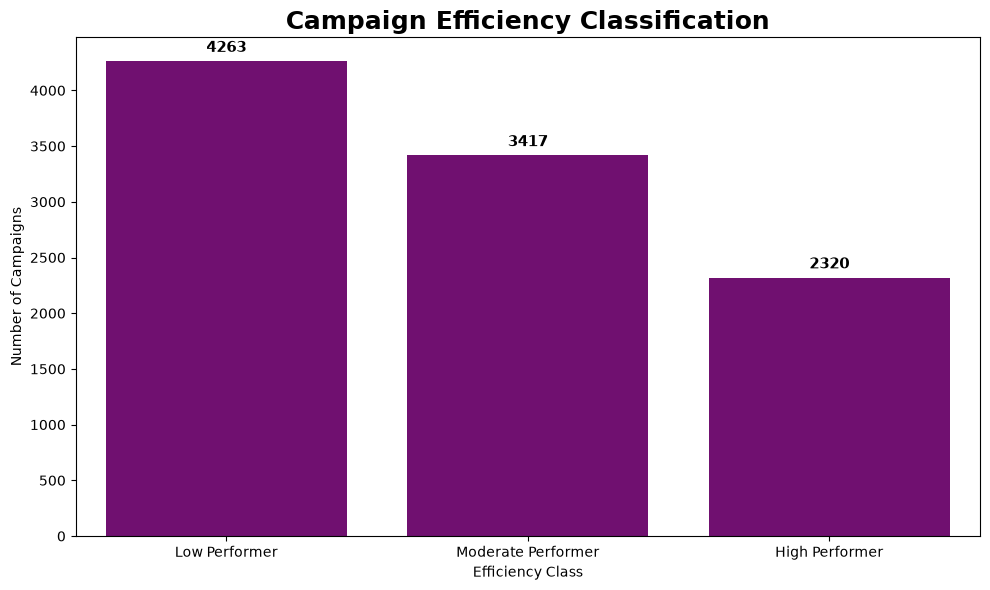

In [20]:
# ============================================================
# EFFICIENCY CLASS DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=efficiency_summary,
    x="Efficiency Class",
    y="Campaigns",
    color =  "purple"
)

plt.title(
    "Campaign Efficiency Classification",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Efficiency Class")
plt.ylabel("Number of Campaigns")

# Add exact counts
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=4,
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

## 4.6 KPI Performance Summary

The KPI performance analysis provided a focused view of the overall effectiveness and efficiency of the marketing campaigns.

### Key Findings

- The dataset contains **10,000 campaigns** with substantial variation in campaign volume, spending, revenue, and profitability.
- CTR, Conversion Rate, ROAS, and Profit were used as the primary indicators of campaign effectiveness.
- Median-based benchmarks were used because several KPIs showed strong right-skewness and extreme values.
- The highest-performing campaigns were identified based on **ROAS and Profit**, while low-performing campaigns were identified using profitability.
- Campaigns were classified into **High, Moderate, and Low Performer** categories using multiple KPI benchmarks.
- The efficiency classification provides a simplified way to distinguish campaigns that consistently perform above or below typical KPI levels.

### Business Implication

The analysis shows that campaign success should not be evaluated using a single KPI. A campaign may achieve strong engagement while producing weak financial returns, or generate high revenue while having inefficient acquisition costs.

Therefore, **CTR, Conversion Rate, ROAS, and Profit should be considered together** when evaluating campaign performance.

The KPI analysis provides the business context required for the next stage of the project: **Feature Engineering**, where relevant campaign characteristics and derived features will be prepared for predictive modeling.